In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv("data/demand_forecasting.csv")

In [13]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [42]:
df.columns = (
    df.columns
    .str.lower()              # alles klein schreiben
    .str.replace(" ", "_")    # Leerzeichen → Unterstrich
)

In [14]:
df.shape

(76000, 16)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [43]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekday"] = df["date"].dt.day_name()

In [44]:
df.isnull().sum()

date                  0
store_id              0
product_id            0
category              0
region                0
inventory_level       0
units_sold            0
units_ordered         0
price                 0
discount              0
weather_condition     0
promotion             0
competitor_pricing    0
seasonality           0
epidemic              0
demand                0
year                  0
month                 0
day                   0
weekday               0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
inventory_level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
units_sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
units_ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
competitor_pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


* time span 2 years: 01.01.22 to 30.01.24
* target variable:
** mean 104, median 100, std 47, max 430 -> right skewed, no extrem outliers (max 4x mean)
** demand > unit sold (mean 104 vs 88) -> lost sales stocksouts
* there are articles with inventory level 0

In [47]:
df.describe(include="object").T

/var/folders/4c/4pm4bwz11292qrczgwq1dmfw0000gn/T/ipykernel_39350/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
store_id,76000,5,S001,15200
product_id,76000,20,P0001,3800
category,76000,5,Groceries,30400
region,76000,4,North,30400
weather_condition,76000,4,Cloudy,24360
seasonality,76000,4,Winter,21000
weekday,76000,7,Saturday,10900


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                76000 non-null  datetime64[us]
 1   store_id            76000 non-null  str           
 2   product_id          76000 non-null  str           
 3   category            76000 non-null  str           
 4   region              76000 non-null  str           
 5   inventory_level     76000 non-null  int64         
 6   units_sold          76000 non-null  int64         
 7   units_ordered       76000 non-null  int64         
 8   price               76000 non-null  float64       
 9   discount            76000 non-null  int64         
 10  weather_condition   76000 non-null  str           
 11  promotion           76000 non-null  int64         
 12  competitor_pricing  76000 non-null  float64       
 13  seasonality         76000 non-null  str           
 14  e

In [49]:
df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'price', 'discount',
       'weather_condition', 'promotion', 'competitor_pricing', 'seasonality',
       'epidemic', 'demand', 'year', 'month', 'day', 'weekday'],
      dtype='str')

In [50]:
df.head(1)

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,promotion,competitor_pricing,seasonality,epidemic,demand,year,month,day,weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday


In [52]:
num_features = ['inventory_level', 'units_sold', 'units_ordered',
                'price', 'discount', 'competitor_pricing', 'demand', 'year', 'month', 'day']

cat_features = ['store_id', 'product_id', 'category', 'region','weather_condition', 'promotion','seasonality', 'epidemic']

date_features = ['date']

In [21]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,year,month,day,weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [22]:
df.groupby("Category")["Units Sold"].sum()

Category
Clothing       1150873
Electronics     757335
Furniture       880654
Groceries      3127335
Toys            834679
Name: Units Sold, dtype: int64

In [23]:
df.groupby("Seasonality")["Units Sold"].sum()

Seasonality
Autumn    1610020
Spring    1535730
Summer    1761945
Winter    1843181
Name: Units Sold, dtype: int64

In [24]:
df.groupby("Region")["Units Sold"].sum()

Region
East     1375613
North    2680946
South    1386126
West     1308191
Name: Units Sold, dtype: int64

In [25]:
df.head(1)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,year,month,day,weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday


In [33]:
df_line = df.groupby(["year", "month"])["Units Sold"].sum().reset_index()

In [34]:
df_line["Date"] = pd.to_datetime(df_line[["year", "month"]].assign(day=1))

In [35]:
df_line.head()

,year,month,Units Sold,Date
0,2022,1,283495,2022-01-01
1,2022,2,271108,2022-02-01
2,2022,3,303752,2022-03-01
3,2022,4,260812,2022-04-01
4,2022,5,205949,2022-05-01


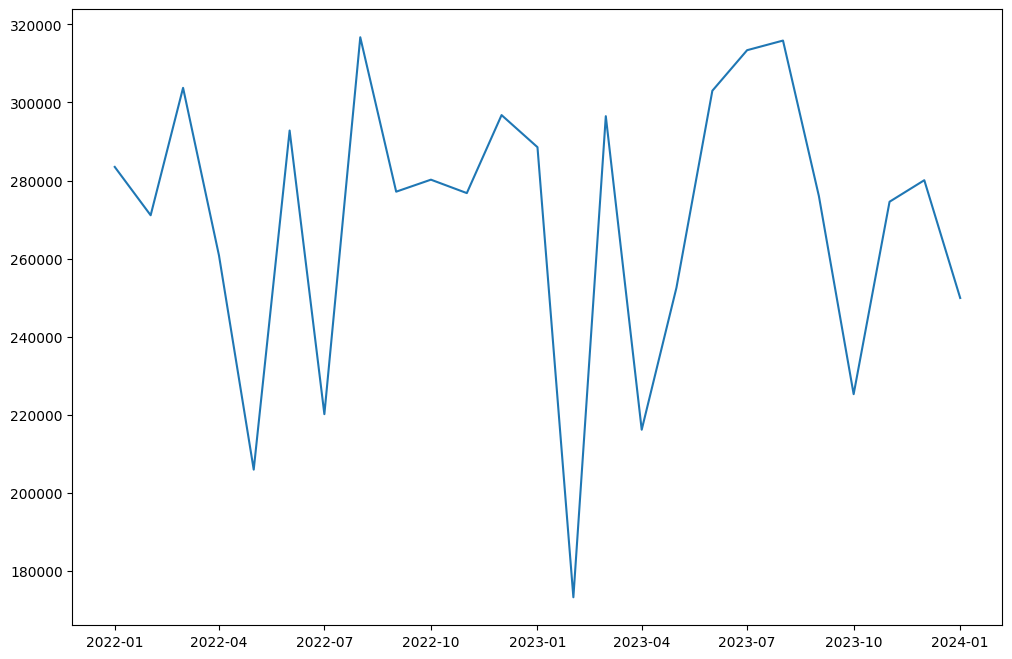

In [37]:
plt.figure(figsize=(12,8))
plt.plot(df_line.Date, df_line["Units Sold"])

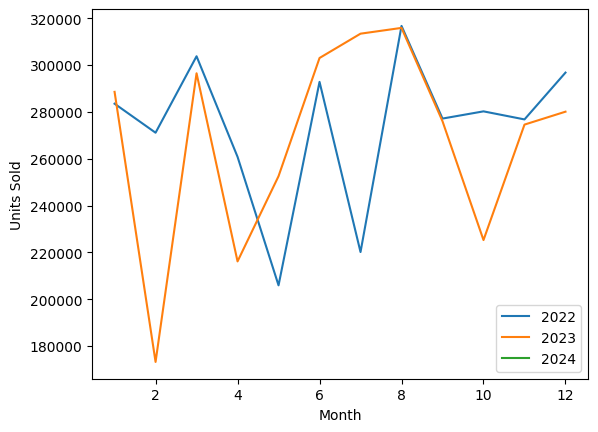

In [38]:
for year in df_line["year"].unique():
    subset = df_line[df_line["year"] == year]
    plt.plot(subset["month"], subset["Units Sold"], label=year)

plt.legend()
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.show()